In [76]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import regex as re

from xgboost import XGBClassifier
from sklearn.metrics import classification_report,confusion_matrix

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize


#Load dataset

In [77]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/oxyJuW.csv')

In [78]:
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [79]:
x=df['text']
y=df['airline_sentiment']

In [80]:
for i in range(20):
  print(x.loc[i])

@VirginAmerica What @dhepburn said.
@VirginAmerica plus you've added commercials to the experience... tacky.
@VirginAmerica I didn't today... Must mean I need to take another trip!
@VirginAmerica it's really aggressive to blast obnoxious "entertainment" in your guests' faces &amp; they have little recourse
@VirginAmerica and it's a really big bad thing about it
@VirginAmerica seriously would pay $30 a flight for seats that didn't have this playing.
it's really the only bad thing about flying VA
@VirginAmerica yes, nearly every time I fly VX this “ear worm” won’t go away :)
@VirginAmerica Really missed a prime opportunity for Men Without Hats parody, there. https://t.co/mWpG7grEZP
@virginamerica Well, I didn't…but NOW I DO! :-D
@VirginAmerica it was amazing, and arrived an hour early. You're too good to me.
@VirginAmerica did you know that suicide is the second leading cause of death among teens 10-24
@VirginAmerica I &lt;3 pretty graphics. so much better than minimal iconography. :D
@V

| Symbol   | Description                           | Example Match                        |      |                       |
| -------- | ------------------------------------- | ------------------------------------ | ---- | --------------------- |
| .      | Any character except newline          | a.c → "abc", "a9c"             |      |                       |
| \d     | Digit (0–9)                           | \d+ → "123"                      |      |                       |
| \D     | Non-digit                             | \D+ → "abc"                      |      |                       |
| \w     | Word character (letters, digits, _) | \w+ → "hello123"                 |      |                       |
| \W     | Non-word character                    | \W+ → "!?@"                      |      |                       |
| \s     | Whitespace (space, tab, newline)      | \s+ → " "                        |      |                       |
| \S     | Non-whitespace                        | \S+ → "word123"                  |      |                       |
| ^      | Start of string                       | ^Hi → matches "Hi there"         |      |                       |
| `$`      | End of string                         | end$ → matches "the end"         |      |                       |
| *      | 0 or more repetitions                 | lo* → "l", "loo", "looo"     |      |                       |
| +      | 1 or more repetitions                 | lo+ → "lo", "loo"              |      |                       |
| ?      | 0 or 1 occurrence                     | colou?r → "color", "colour"    |      |                       |
| {n}    | Exactly n repetitions               | a{3} → "aaa"                     |      |                       |
| {n,}   | At least n repetitions              | a{2,} → "aa", "aaa"            |      |                       |
| {n,m}  | Between n and m repetitions       | a{2,4} → "aa", "aaa", "aaaa" |      |                       |
| [abc]  | Character class (a, b, or c)          | [abc] → "a", "b", "c"        |      |                       |
| [^abc] | Negated character class               | [^abc] → anything except a/b/c   |      |                       |
| (abc)  | Grouping                              | (abc)+ → "abcabc"                |      |                       |
|         |                                      | OR operator                          | cat | dog→"cat"`or"dog"` |
| \b     | Word boundary                         | \bcat\b → "cat", not "scatter" |      |                       |
| \B     | Not a word boundary                   | \Bcat → "scatter", not "cat"   |      |                       |

# Noise removal and tokenisation

In [81]:
#import nltk
#nltk.download('stopwords')
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [82]:
#lets encode the target variable

l=LabelEncoder()
y=l.fit_transform(y)

In [83]:
y

array([1, 2, 1, ..., 1, 0, 1])

In [84]:
def noise_removal(text):
  text=text.lower()
  text=re.sub(r'@\S+','',text)
  text=re.sub(r'http\S+','',text)
  text=re.sub(r'[^a-z ]','',text)

  return text


In [85]:
x=x.apply(noise_removal)
x

,text
0,what said
1,plus youve added commercials to the experienc...
2,i didnt today must mean i need to take anothe...
3,its really aggressive to blast obnoxious ente...
4,and its a really big bad thing about it
...,...
14635,thank you we got on a different flight to chi...
14636,leaving over minutes late flight no warnings...
14637,please bring american airlines to blackberry
14638,you have my money you change my flight and do...


In [86]:
#nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [87]:
#tokenize->remove stopwords->lemmatize
w=WordNetLemmatizer()
s=stopwords.words('english')

def tokenize(x):
  tokens=word_tokenize(x)
  cleaned=[w.lemmatize(words,pos='v') for words in tokens if words.lower() not in s]
  return ' '.join(cleaned)


In [88]:
x=x.apply(tokenize)

#Vectorization

In [89]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=100,stratify=y)

In [90]:
xtrain.shape

(11712,)

In [91]:
xtest.shape

(2928,)

In [92]:
tf=TfidfVectorizer()

In [93]:
tf=TfidfVectorizer()
xtrain=tf.fit_transform(xtrain)
xtest=tf.transform(xtest)

In [94]:
xtrain=pd.DataFrame(xtrain.toarray(),columns=tf.get_feature_names_out())


In [95]:
xtrain

,aa,aaaand,aaadvantage,aaalwayslate,aaba,aacom,aadelay,aadfw,aadv,aadvantage,...,zfv,zip,zipper,zombie,zone,zoom,zrh,zukes,zurich,zurichnew
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11707,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11708,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11709,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11710,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [96]:
xtest=pd.DataFrame(xtest.toarray(),columns=tf.get_feature_names_out())

In [97]:
xtest

,aa,aaaand,aaadvantage,aaalwayslate,aaba,aacom,aadelay,aadfw,aadv,aadvantage,...,zfv,zip,zipper,zombie,zone,zoom,zrh,zukes,zurich,zurichnew
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2923,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2924,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2925,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2926,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [98]:
#lets remove those words that are present <0.1%= 11712*0.1/100≈ 11.7 of documents

(xtrain!=0).mean(axis=0)*100

,0
aa,1.767418
aaaand,0.008538
aaadvantage,0.008538
aaalwayslate,0.008538
aaba,0.017077
...,...
zoom,0.008538
zrh,0.008538
zukes,0.008538
zurich,0.034153


In [99]:
per_data=(xtrain!=0).mean(axis=0)*100
drop_col=per_data[per_data<0.1].index

In [100]:
drop_col

Index(['aaaand', 'aaadvantage', 'aaalwayslate', 'aaba', 'aacom', 'aadelay',
       'aadfw', 'aadv', 'aadvantage', 'aafail',
       ...
       'zfv', 'zip', 'zipper', 'zombie', 'zone', 'zoom', 'zrh', 'zukes',
       'zurich', 'zurichnew'],
      dtype='object', length=8425)

In [101]:
xtrain.drop(columns=drop_col,inplace=True)
xtest.drop(columns=drop_col,inplace=True)

In [102]:
xtrain.shape

(11712, 1125)

#Fitting ML model

In [103]:
xgb=XGBClassifier(n_estimators=200,max_depth=20)

In [104]:
xgb.fit(xtrain,ytrain)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=20,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [105]:
ypred_test=xgb.predict(xtest)

In [106]:
ypred_test

array([0, 0, 0, ..., 1, 1, 2])

In [108]:
print(classification_report(ypred_test,ytest))

              precision    recall  f1-score   support

           0       0.89      0.81      0.85      2010
           1       0.51      0.59      0.55       530
           2       0.61      0.74      0.67       388

    accuracy                           0.77      2928
   macro avg       0.67      0.72      0.69      2928
weighted avg       0.79      0.77      0.77      2928



In [109]:
cm=confusion_matrix(ypred_test,ytest)

In [110]:
cm

array([[1637,  255,  118],
       [ 149,  315,   66],
       [  49,   50,  289]])

<Axes: >

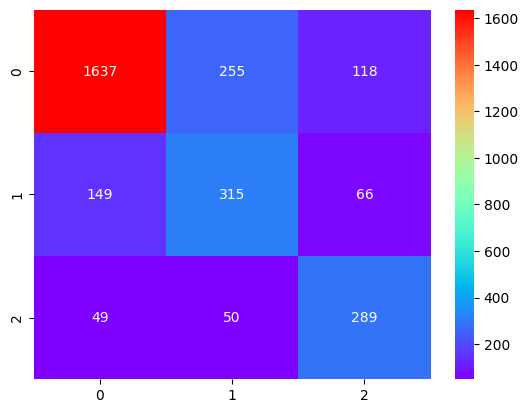

In [112]:
sns.heatmap(cm,annot=True,fmt='d',cmap='rainbow')